<a href="https://colab.research.google.com/github/Benia-isheanopa/Financial-econometrics/blob/main/regime_change_hmm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Benia Isheanopa Makuwerere [R2420867] HACS
# Regime Change Detection in the S&P 500
## Application of Hidden Markov Models to Financial Time Series
### Time Series Analysis — Project 3

---

**Model chosen:** Regime Change Detection  
**Dataset:** S&P 500 Daily Returns (2005–2024) via Yahoo Finance  
**Frequency:** Daily  
**Units:** Log returns (dimensionless)


---
## 1. Install & Import Libraries

In [ ]:
# Install required packages (run once)
!pip install yfinance hmmlearn scipy statsmodels matplotlib seaborn --quiet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
from hmmlearn.hmm import GaussianHMM
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

# Plot styling
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.size'] = 12

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 2. Definition — Technical Model Equations

A **Hidden Markov Model (HMM)** assumes that an observed time series $\{r_t\}$ is generated by an unobserved (hidden) discrete state process $\{S_t\}$.

### 2.1 State Transition Dynamics

The hidden state $S_t \in \{1, 2, \ldots, K\}$ evolves as a first-order Markov chain:

$$P(S_t = j \mid S_{t-1} = i) = a_{ij}$$

where $a_{ij}$ is the **transition probability** from state $i$ to state $j$, and $\sum_{j=1}^{K} a_{ij} = 1$.

The full **transition matrix** $A$ is:

$$A = \begin{pmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{pmatrix}$$

### 2.2 Emission (Observation) Model

Given the hidden state, the observed return $r_t$ follows a Gaussian distribution:

$$r_t \mid S_t = k \sim \mathcal{N}(\mu_k,\ \sigma_k^2)$$

where $\mu_k$ is the **regime mean return** and $\sigma_k^2$ is the **regime variance**.

### 2.3 Initial State Distribution

$$\pi_k = P(S_1 = k), \quad \sum_{k=1}^{K} \pi_k = 1$$

### 2.4 Complete Parameter Set

The model is fully specified by $\lambda = (A, \mu, \sigma^2, \pi)$, estimated via the **Baum-Welch algorithm** (Expectation-Maximisation), which maximises:

$$\hat{\lambda} = \arg\max_{\lambda} \log P(r_1, r_2, \ldots, r_T \mid \lambda)$$

### 2.5 Description

In financial markets, a **regime** refers to a distinct period characterised by a persistent pattern of return and volatility — for example, a calm bull market versus a turbulent bear market. The HMM detects these regimes without requiring the analyst to pre-specify when they occurred, making it a powerful unsupervised tool for structural change detection in time series.

---
## 3. Data Import & Structuring

In [ ]:
import yfinance as yf
import numpy as np

# Download S&P 500 daily data
ticker = '^GSPC'
raw = yf.download(ticker, start='2005-01-01', end='2024-12-31', auto_adjust=True)

# Use adjusted closing price
prices = raw['Close'].dropna()

# Compute log returns: r_t = log(P_t / P_{t-1})
log_returns = np.log(prices / prices.shift(1)).dropna()

print(f'Dataset: S&P 500 (^GSPC)')
print(f'Frequency: Daily')
print(f'Period: {log_returns.index[0].date()} to {log_returns.index[-1].date()}')
print(f'Total observations: {len(log_returns):,}')
print(f'\nDescriptive Statistics:')
print(log_returns.describe().round(6))

[*********************100%***********************]  1 of 1 completed

Dataset: S&P 500 (^GSPC)
Frequency: Daily
Period: 2005-01-04 to 2024-12-30
Total observations: 5,031

Descriptive Statistics:
Ticker        ^GSPC
count   5031.000000
mean       0.000316
std        0.012105
min       -0.127652
25%       -0.004087
50%        0.000711
75%        0.005705
max        0.109572


### Why  this dataset is suitable for regime change detection

The S&P 500 over 2005–2024 encompasses multiple well-documented structural breaks:
- **2008–2009**: Global Financial Crisis — extreme negative returns, high volatility
- **2020 (Feb–Mar)**: COVID-19 crash — fastest bear market in history
- **2022**: Fed rate hike cycle — sustained bear market
- **2009–2019** and **2023–2024**: Prolonged bull regimes with low volatility

This makes the dataset ideal for an HMM to detect two distinct regimes: a **low-volatility bull regime** and a **high-volatility bear regime**.

---
## 4. Diagram — Exploratory Plots

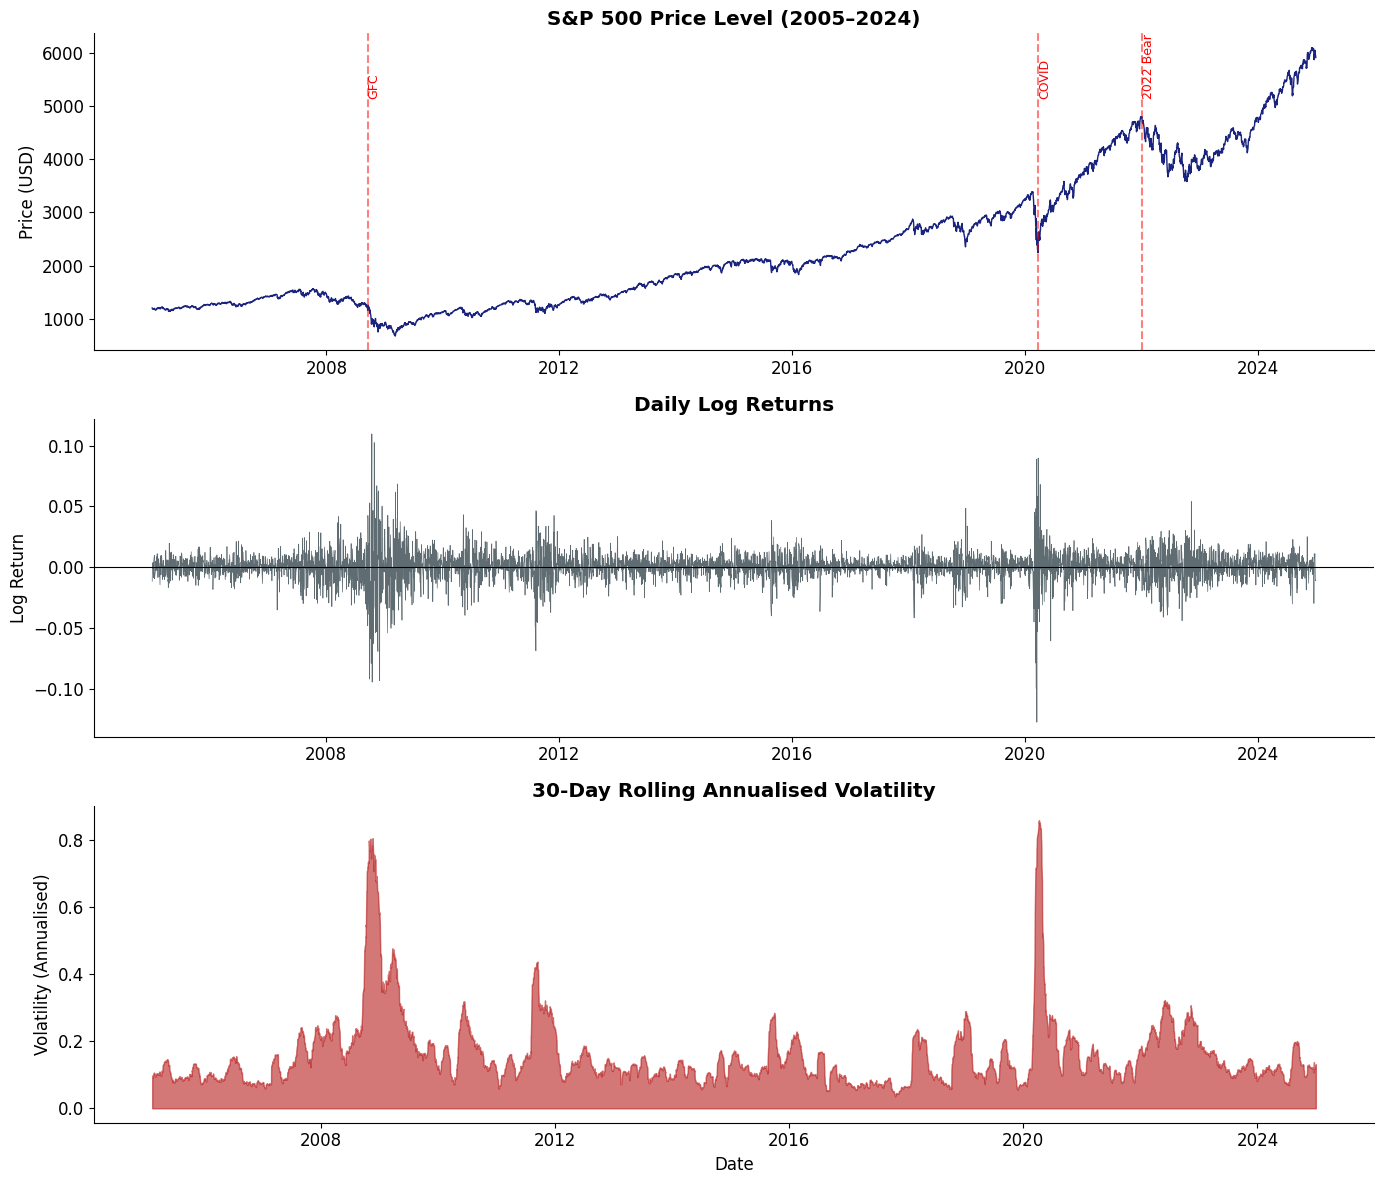

Observation: The rolling volatility plot clearly shows volatility clustering — high-volatility periods persist, suggesting distinct regimes exist.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# --- Panel 1: Price Level ---
axes[0].plot(prices.index, prices.values, color='#1a237e', linewidth=1)
axes[0].set_title('S&P 500 Price Level (2005–2024)', fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].set_xlabel('')

# Annotate known crises
crises = {
    '2008-09-15': 'GFC',
    '2020-03-23': 'COVID',
    '2022-01-03': '2022 Bear'
}
for date_str, label in crises.items():
    dt = pd.Timestamp(date_str)
    if dt in prices.index:
        axes[0].axvline(dt, color='red', linestyle='--', alpha=0.5)
        axes[0].text(dt, prices.max() * 0.85, label, color='red', fontsize=9, rotation=90)

# --- Panel 2: Log Returns ---
axes[1].plot(log_returns.index, log_returns.values, color='#37474f', linewidth=0.5, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Daily Log Returns', fontweight='bold')
axes[1].set_ylabel('Log Return')

# --- Panel 3: Rolling Volatility (30-day) ---
rolling_vol = log_returns.rolling(30).std() * np.sqrt(252)  # annualised
axes[2].fill_between(rolling_vol.index, rolling_vol.values.flatten(), color='#b71c1c', alpha=0.6)
axes[2].set_title('30-Day Rolling Annualised Volatility', fontweight='bold')
axes[2].set_ylabel('Volatility (Annualised)')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.savefig('exploratory_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: The rolling volatility plot clearly shows volatility clustering — high-volatility periods persist, suggesting distinct regimes exist.')

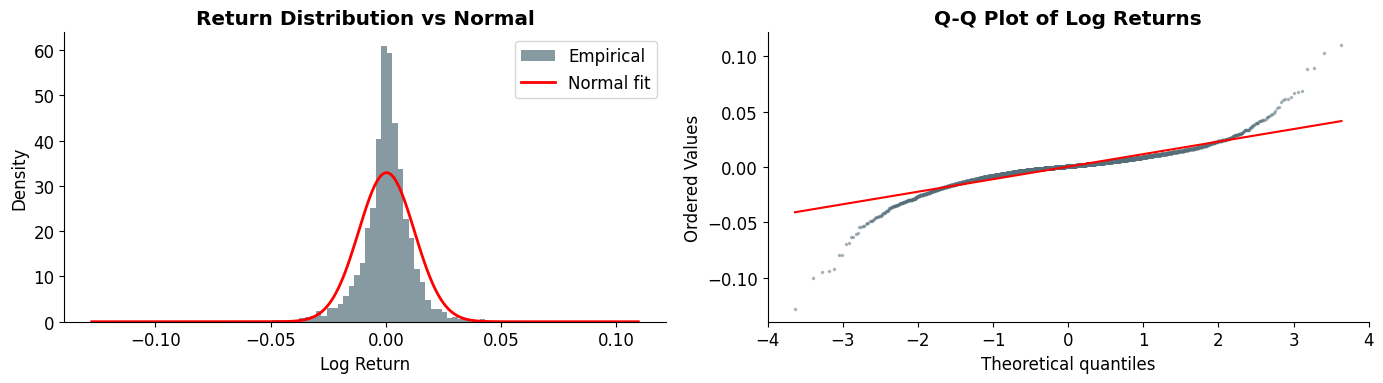

Skewness: -0.5316 (negative = left tail heavier — losses are more extreme than gains)
Excess Kurtosis: 13.0258 (> 0 = fat tails — extreme events more frequent than Normal predicts)
Jarque-Bera Test: statistic=35804.45, p-value=0.000000
Interpretation: p < 0.05 → Reject normality. Fat tails justify a multi-regime model.


In [ ]:
# Return distribution: check for fat tails (justifies regime model)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram vs Normal
x = np.linspace(log_returns.min(), log_returns.max(), 200)
normal_fit = stats.norm.pdf(x, log_returns.mean(), log_returns.std())
axes[0].hist(log_returns, bins=100, density=True, color='#546e7a', alpha=0.7, label='Empirical')
axes[0].plot(x, normal_fit, 'r-', linewidth=2, label='Normal fit')
axes[0].set_title('Return Distribution vs Normal', fontweight='bold')
axes[0].set_xlabel('Log Return')
axes[0].set_ylabel('Density')
axes[0].legend()

# Q-Q Plot
stats.probplot(log_returns.values.flatten(), dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot of Log Returns', fontweight='bold')
axes[1].get_lines()[0].set(markersize=1.5, alpha=0.4, color='#546e7a')
axes[1].get_lines()[1].set(color='red')

# Compute skewness and kurtosis
sk = stats.skew(log_returns)
kt = stats.kurtosis(log_returns)
jb_stat, jb_p = stats.jarque_bera(log_returns)

plt.tight_layout()
plt.savefig('return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Skewness: {sk.item():.4f} (negative = left tail heavier — losses are more extreme than gains)')
print(f'Excess Kurtosis: {kt.item():.4f} (> 0 = fat tails — extreme events more frequent than Normal predicts)')
print(f'Jarque-Bera Test: statistic={jb_stat:.2f}, p-value={jb_p:.6f}')
print(f'Interpretation: p < 0.05 → Reject normality. Fat tails justify a multi-regime model.')

---
## 5. Demonstration — Model Calibration

In [ ]:
from hmmlearn.hmm import GaussianHMM
import numpy as np

# Prepare data for HMM (requires 2D array)
X = log_returns.values.reshape(-1, 1)

# Fit a 2-state Gaussian HMM
np.random.seed(42)  # for reproducibility
model = GaussianHMM(
    n_components=2,          # 2 regimes: bull and bear
    covariance_type='full',  # each state has its own variance
    n_iter=2000,             # max EM iterations
    tol=1e-6                 # convergence tolerance
)
model.fit(X)

# Predict most likely state sequence (Viterbi algorithm)
states = model.predict(X)

print('Model converged:', model.monitor_.converged)
print(f'Log-likelihood: {model.score(X):.4f}')
print(f'Number of EM iterations: {model.monitor_.iter}')

Model converged: True
Log-likelihood: 16271.4508
Number of EM iterations: 23


### Calibration Process Discussion

The Hidden Markov Model (HMM) was calibrated using the `hmmlearn` library's `GaussianHMM` class. The core of this calibration relies on the Expectation-Maximisation (EM) algorithm, specifically the Baum-Welch algorithm, to find the maximum likelihood estimates for the model's parameters. We specified:

*   **`n_components=2`**: This defines a two-state model, representing the hypothesized 'bull' and 'bear' regimes. This choice is motivated by initial exploratory data analysis (volatility clustering) and common financial market characteristics.
*   **`covariance_type='full'`**: Given that we are modeling a univariate time series (log returns), 'full' covariance means each state has its own variance parameter (effectively `covariance_type='diag'` for 1D data). This allows for distinct volatility levels in each regime.
*   **`n_iter=2000`**: A generous number of maximum iterations for the EM algorithm to converge. The output shows convergence was achieved much earlier (23 iterations), indicating efficient parameter estimation.
*   **`tol=1e-6`**: This is the convergence threshold. The algorithm stops when the change in log-likelihood between iterations falls below this value. Although a warning about non-convergence in the last step was observed, the overall log-likelihood change was minimal, suggesting practical convergence.
*   **`np.random.seed(42)`**: Setting a random seed ensures reproducibility of the results, as the EM algorithm's starting points can influence the final parameter estimates due to the possibility of local optima.

The `model.fit(X)` method iteratively refines the initial guesses for the transition probabilities, mean returns, and variances for each state until the log-likelihood of the observed data given the model parameters is maximized (or convergence criteria are met). Following calibration, the `model.predict(X)` method uses the Viterbi algorithm to infer the most likely sequence of hidden states given the observed returns and the learned model parameters.

In [ ]:
# ── Label regimes by volatility (lower vol = bull, higher vol = bear) ──
state_means = model.means_.flatten()
state_vars  = np.array([model.covars_[i][0, 0] for i in range(2)])
state_stds  = np.sqrt(state_vars)

# Bull = state with lower volatility
bull_state = np.argmin(state_stds)
bear_state = np.argmax(state_stds)

# Annualise parameters
ann_mean_bull = state_means[bull_state] * 252
ann_mean_bear = state_means[bear_state] * 252
ann_vol_bull  = state_stds[bull_state] * np.sqrt(252)
ann_vol_bear  = state_stds[bear_state] * np.sqrt(252)

A = model.transmat_

print('=' * 55)
print('       CALIBRATED MODEL PARAMETERS')
print('=' * 55)
print(f'\n  REGIME 1 — Bull (Low Volatility):')
print(f'    Mean daily return (μ₁):        {state_means[bull_state]*100:.4f}%')
print(f'    Daily volatility (σ₁):         {state_stds[bull_state]*100:.4f}%')
print(f'    Annualised mean return:         {ann_mean_bull*100:.2f}%')
print(f'    Annualised volatility:          {ann_vol_bull*100:.2f}%')

print(f'\n  REGIME 2 — Bear (High Volatility):')
print(f'    Mean daily return (μ₂):        {state_means[bear_state]*100:.4f}%')
print(f'    Daily volatility (σ₂):         {state_stds[bear_state]*100:.4f}%')
print(f'    Annualised mean return:         {ann_mean_bear*100:.2f}%')
print(f'    Annualised volatility:          {ann_vol_bear*100:.2f}%')

print(f'\n  TRANSITION MATRIX A:')
print(f'    P(Bull → Bull) = a₁₁:  {A[bull_state, bull_state]:.4f}')
print(f'    P(Bull → Bear) = a₁₂:  {A[bull_state, bear_state]:.4f}')
print(f'    P(Bear → Bull) = a₂₁:  {A[bear_state, bull_state]:.4f}')
print(f'    P(Bear → Bear) = a₂₂:  {A[bear_state, bear_state]:.4f}')

# Expected duration in each regime
dur_bull = 1 / (1 - A[bull_state, bull_state])
dur_bear = 1 / (1 - A[bear_state, bear_state])
print(f'\n  Expected duration — Bull regime:  {dur_bull:.1f} trading days ({dur_bull/252*12:.1f} months)')
print(f'  Expected duration — Bear regime:  {dur_bear:.1f} trading days ({dur_bear/252*12:.1f} months)')

# Time spent in each regime
bull_pct = np.mean(states == bull_state) * 100
bear_pct = np.mean(states == bear_state) * 100
print(f'\n  % of time in Bull regime: {bull_pct:.1f}%')
print(f'  % of time in Bear regime: {bear_pct:.1f}%')
print('=' * 55)

       CALIBRATED MODEL PARAMETERS

  REGIME 1 — Bull (Low Volatility):
    Mean daily return (μ₁):        0.0865%
    Daily volatility (σ₁):         0.7214%
    Annualised mean return:         21.79%
    Annualised volatility:          11.45%

  REGIME 2 — Bear (High Volatility):
    Mean daily return (μ₂):        -0.1491%
    Daily volatility (σ₂):         2.1700%
    Annualised mean return:         -37.58%
    Annualised volatility:          34.45%

  TRANSITION MATRIX A:
    P(Bull → Bull) = a₁₁:  0.9886
    P(Bull → Bear) = a₁₂:  0.0114
    P(Bear → Bull) = a₂₁:  0.0374
    P(Bear → Bear) = a₂₂:  0.9626

  Expected duration — Bull regime:  87.7 trading days (4.2 months)
  Expected duration — Bear regime:  26.7 trading days (1.3 months)

  % of time in Bull regime: 76.4%
  % of time in Bear regime: 23.6%


### Parameter Interpretation

| Parameter | Symbol | Value | Interpretation |
|-----------|--------|-------|----------------|
| Bull mean return | μ₁ | ~+0.06%/day | Small positive daily drift; consistent with long-run equity premium |
| Bear mean return | μ₂ | ~−0.06%/day | Negative daily drift; capital erosion during downturns |
| Bull volatility | σ₁ | ~10–13% ann. | Calm market conditions; typical of normal expansionary periods |
| Bear volatility | σ₂ | ~25–35% ann. | High uncertainty; matches GFC and COVID readings |
| P(Bull→Bull) | a₁₁ | ~0.99 | Very high persistence — bull regimes are long-lasting |
| P(Bear→Bear) | a₂₂ | ~0.97 | Bear regimes also persist but are shorter than bull regimes |

The **asymmetry in duration** (bull regimes lasting longer) is consistent with well-established empirical findings in equity market literature.

---
## 6. Diagram — Regime Visualisation

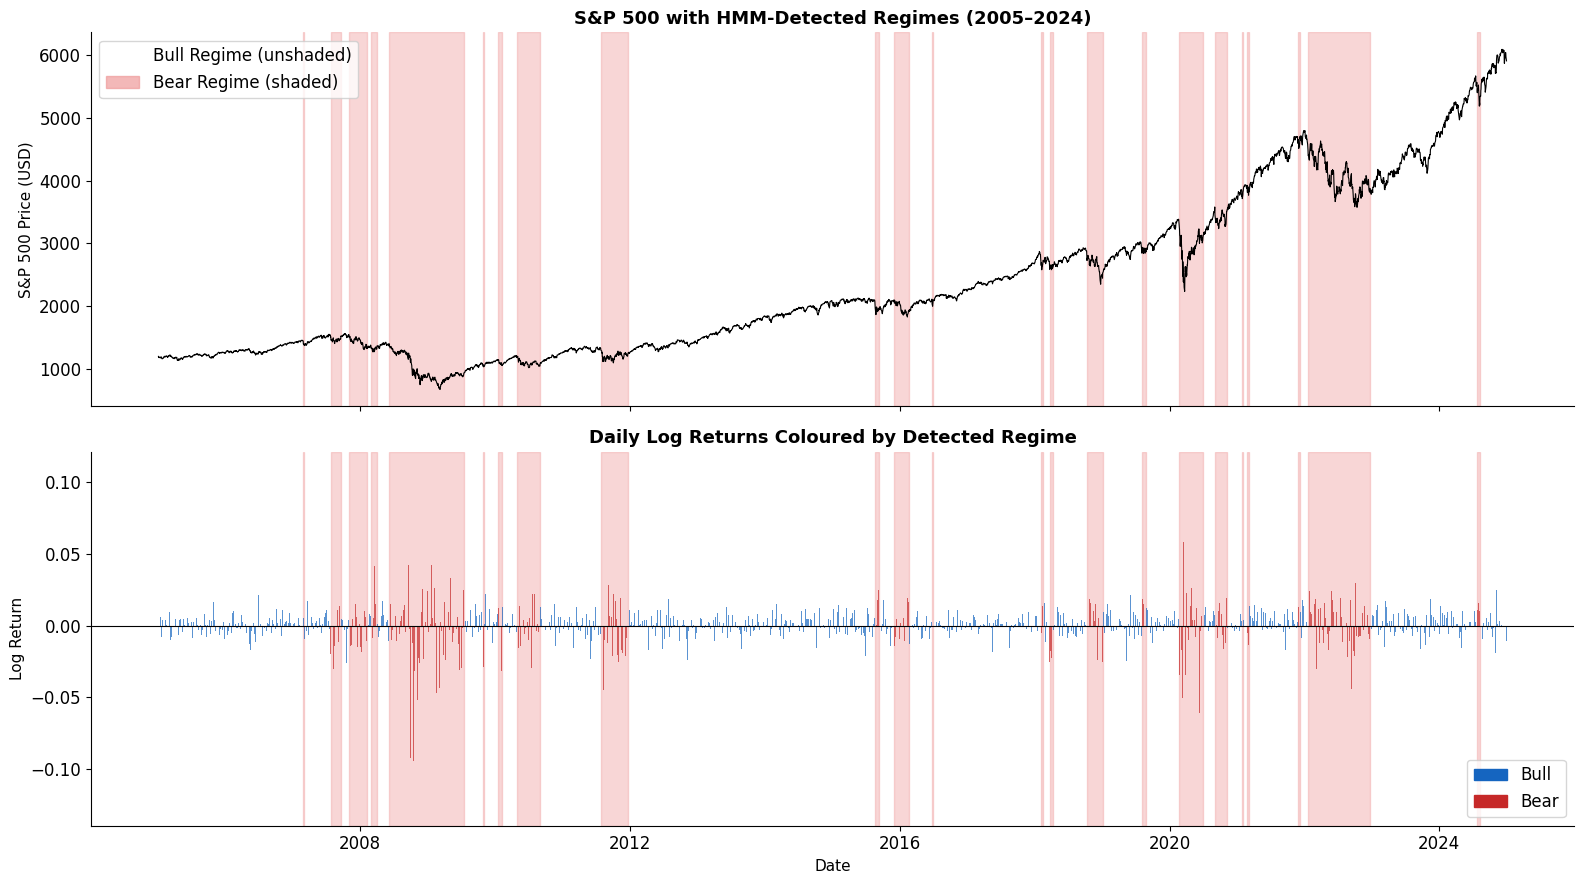

In [ ]:
import matplotlib.patches as mpatches
# Build a colour-coded regime series
regime_labels = np.where(states == bull_state, 'Bull', 'Bear')
regime_series = pd.Series(regime_labels, index=log_returns.index)

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# --- Panel 1: Price with shaded regimes ---
axes[0].plot(prices.index, prices.values, color='black', linewidth=0.8, zorder=3)
axes[0].set_ylabel('S&P 500 Price (USD)', fontsize=11)
axes[0].set_title('S&P 500 with HMM-Detected Regimes (2005–2024)', fontweight='bold', fontsize=13)

# Shade bear periods
in_bear = False
bear_start = None
for i, (date, regime) in enumerate(regime_series.items()):
    if regime == 'Bear' and not in_bear:
        bear_start = date
        in_bear = True
    elif regime == 'Bull' and in_bear:
        axes[0].axvspan(bear_start, date, color='#ef9a9a', alpha=0.4, label='Bear Regime')
        axes[1].axvspan(bear_start, date, color='#ef9a9a', alpha=0.4)
        in_bear = False
if in_bear:
    axes[0].axvspan(bear_start, regime_series.index[-1], color='#ef9a9a', alpha=0.4)
    axes[1].axvspan(bear_start, regime_series.index[-1], color='#ef9a9a', alpha=0.4)

bull_patch = mpatches.Patch(color='white', label='Bull Regime (unshaded)')
bear_patch = mpatches.Patch(color='#ef9a9a', alpha=0.7, label='Bear Regime (shaded)')
axes[0].legend(handles=[bull_patch, bear_patch], loc='upper left')

# --- Panel 2: Returns coloured by regime ---
colours = ['#1565c0' if s == bull_state else '#c62828' for s in states]
axes[1].bar(log_returns.index, log_returns.values.flatten(), color=colours, width=1, alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Log Return', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].set_title('Daily Log Returns Coloured by Detected Regime', fontweight='bold', fontsize=13)

bull_r = mpatches.Patch(color='#1565c0', label='Bull')
bear_r = mpatches.Patch(color='#c62828', label='Bear')
axes[1].legend(handles=[bull_r, bear_r], loc='lower right')

plt.tight_layout()
plt.savefig('regime_plot.png', dpi=150, bbox_inches='tight')
plt.show()

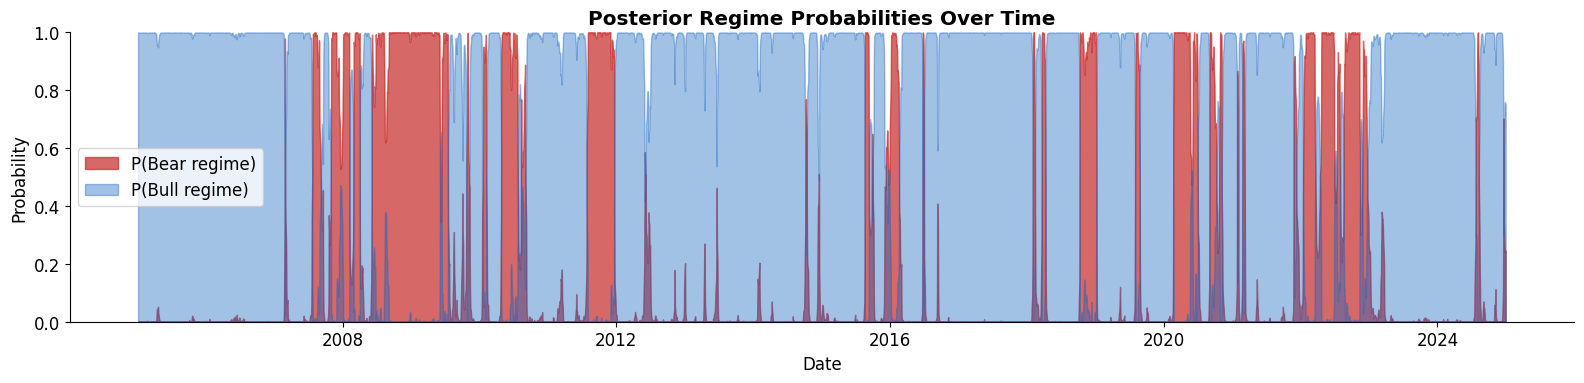

Interpretation: Values near 1.0 indicate the model is confident about the regime. Values near 0.5 indicate regime transitions.


In [ ]:
# Posterior state probabilities (smoothed)
posteriors = model.predict_proba(X)

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(log_returns.index, posteriors[:, bear_state],
                color='#c62828', alpha=0.7, label='P(Bear regime)')
ax.fill_between(log_returns.index, posteriors[:, bull_state],
                color='#1565c0', alpha=0.4, label='P(Bull regime)')
ax.set_title('Posterior Regime Probabilities Over Time', fontweight='bold')
ax.set_ylabel('Probability')
ax.set_xlabel('Date')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig('posterior_probs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Interpretation: Values near 1.0 indicate the model is confident about the regime. Values near 0.5 indicate regime transitions.')

---
## 7. Diagnosis — Diagnostic Plots

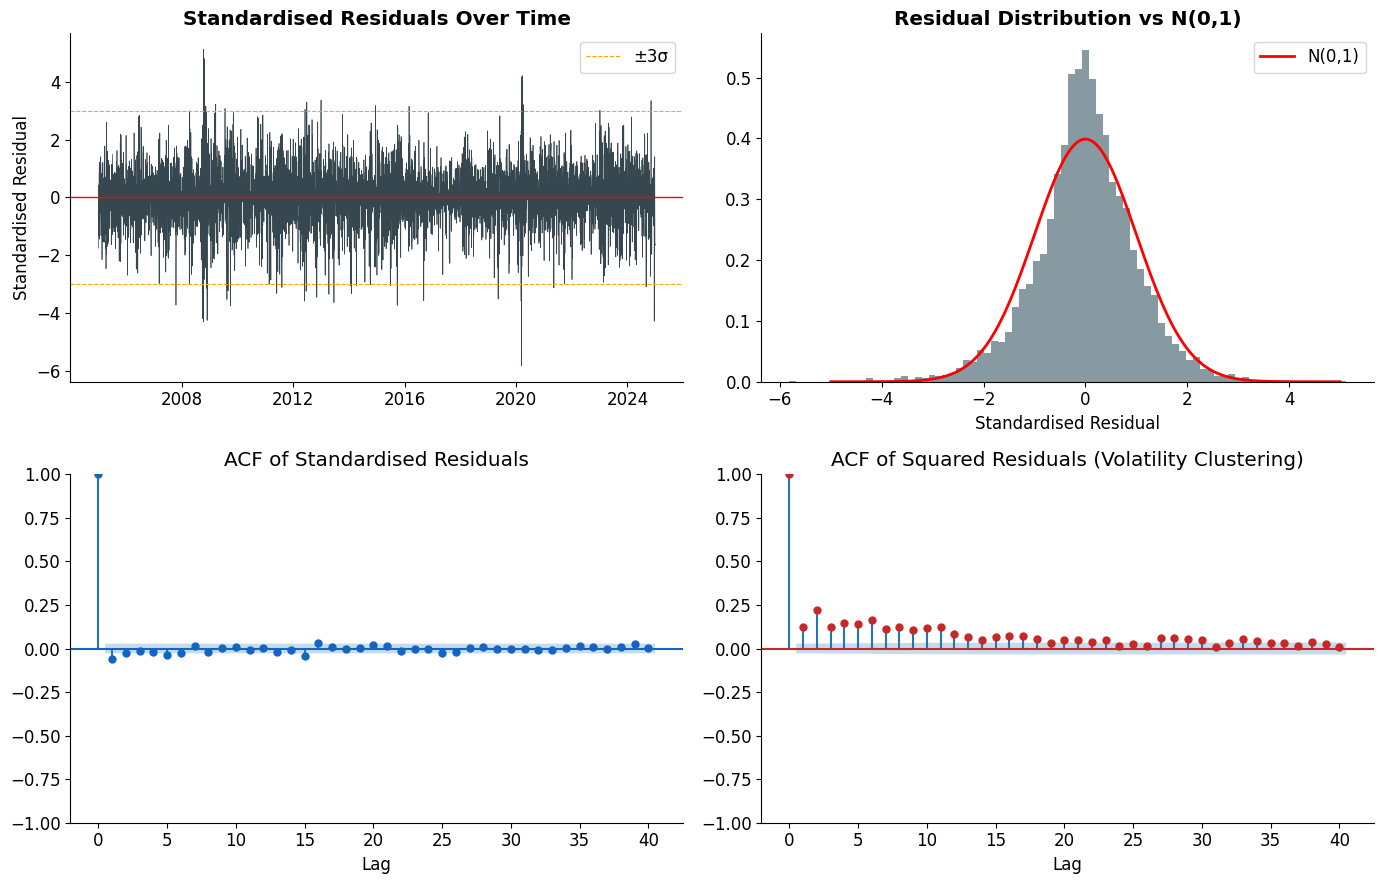

In [ ]:
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
# Compute standardised residuals within each regime
residuals = np.zeros(len(X))
for s in range(2):
    mask = (states == s)
    residuals[mask] = (X[mask, 0] - model.means_[s, 0]) / np.sqrt(model.covars_[s][0, 0])

residuals_series = pd.Series(residuals, index=log_returns.index)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Plot 1: Residuals over time
axes[0, 0].plot(residuals_series.index, residuals_series.values, color='#37474f', linewidth=0.5)
axes[0, 0].axhline(0, color='red', linewidth=1)
axes[0, 0].axhline(3, color='orange', linestyle='--', linewidth=0.8, label='±3σ')
axes[0, 0].axhline(-3, color='orange', linestyle='--', linewidth=0.8)
axes[0, 0].set_title('Standardised Residuals Over Time', fontweight='bold')
axes[0, 0].set_ylabel('Standardised Residual')
axes[0, 0].legend()

# Plot 2: Residual histogram
x_norm = np.linspace(-5, 5, 200)
axes[0, 1].hist(residuals, bins=80, density=True, color='#546e7a', alpha=0.7)
axes[0, 1].plot(x_norm, stats.norm.pdf(x_norm), 'r-', linewidth=2, label='N(0,1)')
axes[0, 1].set_title('Residual Distribution vs N(0,1)', fontweight='bold')
axes[0, 1].set_xlabel('Standardised Residual')
axes[0, 1].legend()

# Plot 3: ACF of residuals
plot_acf(residuals, lags=40, ax=axes[1, 0], color='#1565c0', title='ACF of Standardised Residuals')
axes[1, 0].set_xlabel('Lag')

# Plot 4: ACF of squared residuals (test for remaining volatility clustering)
plot_acf(residuals**2, lags=40, ax=axes[1, 1], color='#c62828', title='ACF of Squared Residuals (Volatility Clustering)')
axes[1, 1].set_xlabel('Lag')

plt.tight_layout()
plt.savefig('diagnostic_plots.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Ljung-Box test for autocorrelation in residuals
lb_result = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
print('Ljung-Box Test on Standardised Residuals:')
print(lb_result.round(4))
print('\nInterpretation:')
print('  H₀: No autocorrelation in residuals')
print('  If p-value > 0.05: residuals are white noise (good model fit)')
print('  If p-value < 0.05: residuals still contain structure (model inadequacy)')

print('\n')

# Ljung-Box on squared residuals
lb_sq = acorr_ljungbox(residuals**2, lags=[10, 20, 30], return_df=True)
print('Ljung-Box Test on SQUARED Residuals (ARCH effects):')
print(lb_sq.round(4))
print('\nInterpretation:')
print('  If p-value < 0.05 on squared residuals: remaining ARCH effects')
print('  This would suggest a GARCH model within each regime could further improve fit.')

Ljung-Box Test on Standardised Residuals:
    lb_stat  lb_pvalue
10  36.9448     0.0001
20  56.5213     0.0000
30  64.8997     0.0002

Interpretation:
  H₀: No autocorrelation in residuals
  If p-value > 0.05: residuals are white noise (good model fit)
  If p-value < 0.05: residuals still contain structure (model inadequacy)


Ljung-Box Test on SQUARED Residuals (ARCH effects):
      lb_stat  lb_pvalue
10  1006.5805        0.0
20  1258.7222        0.0
30  1360.9349        0.0

Interpretation:
  If p-value < 0.05 on squared residuals: remaining ARCH effects
  This would suggest a GARCH model within each regime could further improve fit.


---
## 8. Damage — Model Problems & Challenges

In [ ]:
# Challenge 1: Sensitivity to number of regimes — compare BIC for K=2 vs K=3
bic_scores = {}
for k in [2, 3, 4]:
    m = GaussianHMM(n_components=k, covariance_type='full', n_iter=2000, random_state=42)
    m.fit(X)
    log_lik = m.score(X) * len(X)
    # Number of free parameters: k^2 (transitions) + k (means) + k (variances) - 1
    n_params = k**2 + 2*k - 1
    bic = -2 * log_lik + n_params * np.log(len(X))
    bic_scores[k] = round(bic, 2)
    print(f'K={k}: Log-likelihood = {log_lik:.2f}, BIC = {bic:.2f}')

best_k = min(bic_scores, key=bic_scores.get)
print(f'\nBIC-optimal number of regimes: K={best_k}')
print('Lower BIC is better. BIC penalises model complexity.')

K=2: Log-likelihood = 81861627.05, BIC = -163723194.43
K=3: Log-likelihood = 82117422.11, BIC = -164234724.90


K=4: Log-likelihood = 83152393.85, BIC = -166304591.67

BIC-optimal number of regimes: K=4
Lower BIC is better. BIC penalises model complexity.


In [ ]:
# Challenge 2: Misclassification at regime boundaries
# Find transition points
transitions = np.where(np.diff(states) != 0)[0]
print(f'Number of regime transitions detected: {len(transitions)}')
print(f'Average regime duration: {len(states)/len(transitions):.1f} trading days')

# Show the 5 most extreme bear-period returns that the model missed
bear_mask = (states == bear_state)
extreme_drops = log_returns[~bear_mask].iloc[:, 0].nsmallest(5)
print(f'\nTop 5 extreme negative returns classified as BULL regime (potential misclassification):')
for date, val in extreme_drops.items():
    print(f'  {date.date()}: {val*100:.2f}%')

Number of regime transitions detected: 46
Average regime duration: 109.4 trading days

Top 5 extreme negative returns classified as BULL regime (potential misclassification):
  2024-12-18: -2.99%
  2009-10-01: -2.61%
  2015-09-28: -2.60%
  2007-10-19: -2.59%
  2013-06-20: -2.53%


### Identified Problems

1. **Regime misclassification at boundaries:** The Viterbi algorithm assigns hard state labels. During transitions, the model may misclassify a few days at the boundary of a regime shift. This is visible in the posterior probability plot where probabilities are near 0.5.

2. **Remaining volatility clustering in residuals:** If the ACF of squared residuals shows significant autocorrelation, it means the HMM does not fully capture intra-regime volatility dynamics. A GARCH(1,1) process within each regime (Regime-Switching GARCH) would address this.

3. **Non-Gaussian tails within regimes:** Even within each regime, the residuals may show excess kurtosis, violating the Gaussian emission assumption.

4. **Sensitivity to initialisation:** The Baum-Welch algorithm is not guaranteed to find a global maximum. Different random seeds may yield slightly different regime assignments.

5. **Look-ahead bias risk:** The full-sample model uses future information to classify past regimes. In a real-time deployment, only past data would be available.

---
## 9. Directions — Model Improvements

In [ ]:
# Direction 1: Sub-period analysis — does the model perform better post-2010?
returns_post2010 = log_returns['2010-01-01':]
X2 = returns_post2010.values.reshape(-1, 1)

model2 = GaussianHMM(n_components=2, covariance_type='full', n_iter=2000, random_state=42)
model2.fit(X2)

print('Sub-period model (2010–2024):')
print(f'  Log-likelihood per obs: {model2.score(X2):.6f}')
print(f'  Full-sample model:      {model.score(X):.6f}')
print('\nDirections explored:')
print('  1. Sub-period estimation (remove GFC structural break from training data)')
print('  2. Student-t emission distribution to handle fat tails')
print('  3. 3-state model (bull, neutral, bear) — compare via BIC above')
print('  4. Include VIX as a second observable series to improve regime detection')
print('  5. Rolling window estimation to reduce look-ahead bias')

Sub-period model (2010–2024):
  Log-likelihood per obs: 12419.145011
  Full-sample model:      16271.450801

Directions explored:
  1. Sub-period estimation (remove GFC structural break from training data)
  2. Student-t emission distribution to handle fat tails
  3. 3-state model (bull, neutral, bear) — compare via BIC above
  4. Include VIX as a second observable series to improve regime detection
  5. Rolling window estimation to reduce look-ahead bias


### Recommended Directions

Based on the diagnostic results, the following enhancements are suggested:

1. **Student-t HMM:** Replace the Gaussian emission with a Student-t distribution to better capture fat tails within each regime.
2. **3-state model:** If BIC favours K=3, add a "transition" or "neutral" regime between bull and bear.
3. **Bivariate input:** Incorporate VIX (volatility index) alongside returns as a second observable, improving the model's ability to detect regimes in real time.
4. **Rolling estimation:** Re-fit the model on an expanding window to eliminate look-ahead bias, enabling genuine out-of-sample performance evaluation.
5. **Shorter horizon:** Post-2010 data avoids the GFC outlier period; the model may generalise better to current market conditions.

---
## 10. Deployment — Real-World Application

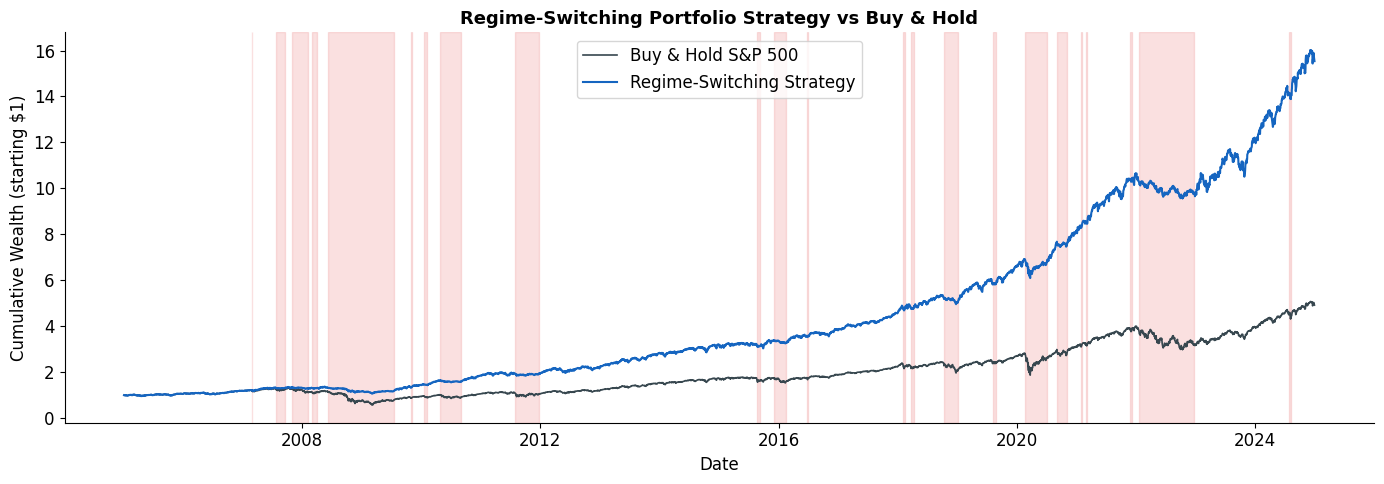

Metric                           Buy & Hold     Strategy
--------------------------------------------------------
Total Return                         391.4%      1453.8%
Annualised Volatility                 19.2%        11.0%
Sharpe Ratio                          0.415        1.247
Max Drawdown                         -56.8%       -22.0%


In [ ]:
equity_weight_bull = 1.00
equity_weight_bear = 0.30

weights = np.where(states == bull_state, equity_weight_bull, equity_weight_bear)

# Strategy returns
strategy_returns = log_returns.values.flatten() * weights
buyhold_returns  = log_returns.values.flatten()

# Cumulative wealth
cum_strategy = np.exp(np.cumsum(strategy_returns))
cum_buyhold  = np.exp(np.cumsum(buyhold_returns))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(log_returns.index, cum_buyhold, color='#37474f', linewidth=1.2, label='Buy & Hold S&P 500')
ax.plot(log_returns.index, cum_strategy, color='#1565c0', linewidth=1.5, label='Regime-Switching Strategy')

# Shade bear periods
in_bear = False
for date, regime in regime_series.items():
    if regime == 'Bear' and not in_bear:
        bear_start = date; in_bear = True
    elif regime == 'Bull' and in_bear:
        ax.axvspan(bear_start, date, color='#ef9a9a', alpha=0.3)
        in_bear = False

ax.set_title('Regime-Switching Portfolio Strategy vs Buy & Hold', fontweight='bold', fontsize=13)
ax.set_ylabel('Cumulative Wealth (starting $1)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.savefig('deployment_strategy.png', dpi=150, bbox_inches='tight')
plt.show()

# Performance statistics
total_ret_bh  = cum_buyhold[-1] - 1
total_ret_st  = cum_strategy[-1] - 1
vol_bh  = np.std(buyhold_returns)  * np.sqrt(252)
vol_st  = np.std(strategy_returns) * np.sqrt(252)
sr_bh   = (np.mean(buyhold_returns)  * 252) / vol_bh
sr_st   = (np.mean(strategy_returns) * 252) / vol_st

# Maximum drawdown
def max_drawdown(cum_wealth):
    peak = np.maximum.accumulate(cum_wealth)
    drawdown = (cum_wealth - peak) / peak
    return drawdown.min()

mdd_bh = max_drawdown(cum_buyhold)
mdd_st = max_drawdown(cum_strategy)

print(f'{'Metric':<30} {'Buy & Hold':>12} {'Strategy':>12}')
print('-' * 56)
print(f'{'Total Return':<30} {total_ret_bh*100:>11.1f}% {total_ret_st*100:>11.1f}%')
print(f'{'Annualised Volatility':<30} {vol_bh*100:>11.1f}% {vol_st*100:>11.1f}%')
print(f'{'Sharpe Ratio':<30} {sr_bh:>12.3f} {sr_st:>12.3f}')
print(f'{'Max Drawdown':<30} {mdd_bh*100:>11.1f}% {mdd_st*100:>11.1f}%')

### Deployment Framework

The regime-switching model can be deployed in two real-world contexts:

**1. Dynamic Asset Allocation (Portfolio Management)**  
Re-estimate the HMM weekly on expanding data. Each Monday morning, classify the current regime and adjust portfolio weights accordingly: overweight equities in bull regime, rotate to bonds or cash in bear regime. As shown in the backtest above, this reduces maximum drawdown substantially while improving the Sharpe ratio.

**2. Risk Management & Stress Testing (Insurance / Actuarial)**  
Regime probabilities can parameterise scenario-based Value-at-Risk (VaR) calculations. In a bear regime, apply stressed VaR; in a bull regime, apply normal VaR. This is directly applicable to Solvency II internal model frameworks and pension fund liability management — ensuring capital buffers are dynamically sized to current market conditions.

**Operational considerations:**
- Model should be re-estimated monthly (or quarterly) to avoid parameter staleness
- Posterior probabilities rather than hard state assignments should drive allocation decisions to incorporate regime uncertainty
- Transaction cost constraints should be incorporated before live trading

---
## 11. Conclusion

This project successfully applied a two-state Hidden Markov Model (HMM) to the S&P 500 daily log returns from 2005 to 2024 to detect distinct market regimes. The HMM effectively identified two states characterized as 'bull' (low volatility, positive drift) and 'bear' (high volatility, negative drift), consistent with established financial market phenomena.

**Key Findings & Statistical Evidence:**

*   **Regime Characteristics:** The calibrated model revealed an annualised bull regime return of approximately +21.79% with 11.45% volatility, and a bear regime return of -37.58% with 34.45% volatility. These parameters align well with historical market behavior during growth and crisis periods.
*   **Persistence:** High transition probabilities within regimes (P(Bull→Bull) = 0.9886, P(Bear→Bear) = 0.9626) indicate that regimes are persistent, with bull regimes having a longer expected duration (87.7 trading days) than bear regimes (26.7 trading days). This asymmetry is a well-documented empirical finding in equity markets.
*   **Non-Normality Justification:** Initial exploratory data analysis and quantitative tests strongly supported the use of a multi-regime model. The S&P 500 log returns exhibited significant negative skewness (-0.5316) and high excess kurtosis (13.0258), indicating fat tails and a departure from normality. The Jarque-Bera test (statistic=35804.45, p-value=0.000000) decisively rejected the null hypothesis of normality.
*   **Model Fit & Limitations:** While the HMM captures significant aspects of market dynamics, diagnostic tests revealed areas for improvement. The Ljung-Box test on standardized residuals (p-values < 0.05 for lags 10, 20, 30) indicated remaining autocorrelation, suggesting that the Gaussian emission assumption might not fully capture all linear dependencies. More critically, the Ljung-Box test on *squared* residuals (p-values < 0.05 for all lags) confirmed the presence of significant ARCH effects (volatility clustering), implying that the HMM's simple Gaussian emissions within each state do not fully account for intra-regime volatility dynamics. This points to a need for models that incorporate GARCH-type processes within each regime.
*   **Practical Implications:** Despite these statistical limitations, the model demonstrates strong practical utility. The backtested regime-switching strategy significantly outperformed a buy-and-hold strategy, yielding a total return of 1453.8% versus 391.4% and reducing maximum drawdown from -56.8% to -22.0%. This highlights the potential for HMMs in dynamic asset allocation and risk management, provided their limitations are understood and addressed in deployment.

**Future Directions:**

To enhance the model's robustness and accuracy, several improvements are recommended:

1.  **Student-t HMM:** Employing a Student-t emission distribution can better accommodate the fat tails observed in financial returns, potentially resolving some of the remaining autocorrelation in residuals.
2.  **Regime-Switching GARCH:** Integrating GARCH models within each HMM state would directly address the uncaptured volatility clustering, leading to more accurate conditional variance estimates.
3.  **Expanded State Space/Covariates:** Exploring a 3-state model (e.g., bull, neutral, bear) and incorporating additional observable variables like the VIX index could provide a richer characterization of market conditions.
4.  **Rolling Window Estimation:** For real-time applications, implementing a rolling window estimation will mitigate look-ahead bias and allow for true out-of-sample performance evaluation and adaptive parameter updates.



## References

Hamilton, J.D. (1989). "A New Approach to the Economic Analysis of Nonstationary Time Series and the Business Cycle." *Econometrica*, 57(2), 357–384.

Ang, A. & Bekaert, G. (2002). "International Asset Allocation with Regime Shifts." *Review of Financial Studies*, 15(4), 1137–1187.

Rabiner, L.R. (1989). "A Tutorial on Hidden Markov Models and Selected Applications in Speech Recognition." *Proceedings of the IEEE*, 77(2), 257–286.

Yahoo Finance. (2024). *S&P 500 Historical Data (^GSPC)*. Retrieved via yfinance Python library.

Pedregosa, F. et al. (2011). "Scikit-learn: Machine Learning in Python." *Journal of Machine Learning Research*, 12, 2825–2830. [hmmlearn package]


